In [2]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(scRepertoire)

In [3]:
so <- readRDS('seurat_objects/clean_jurkat_raji_so_3.rds')

In [4]:
so$combined_names <- 'NA'
so$combined_names[so$orig.ident %in% c('Jur_Raji_1','Jur_Raji_2')] <- 'Jurkat Raji Mixture'
so$combined_names[so$orig.ident %in% c('Jurkat_1','Jurkat_2')] <- 'Jurkat Only'
so$combined_names[so$orig.ident %in% c('Raji_1','Raji_2')] <- 'Raji Only'
table(so$combined_names)


        Jurkat Only Jurkat Raji Mixture           Raji Only 
               6901               26521               10607 

In [5]:
so_split <- SplitObject(so, split.by = 'orig.ident')
names(so_split)

[1] "Jurkat_1"   "Jurkat_2"   "Jur_Raji_1" "Jur_Raji_2" "Raji_1"    
[6] "Raji_2"

In [6]:
add_clones_func <- function(ident_name){
    # load corrent Seurat Object
    so_subset <- so_split[[ident_name]]
    
    # read in clones
    clones <- loadContigs(input = paste0('../../reflex_data/Jurkat_Raji_TCR_poc/',ident_name,'/'), format = 'MiXCR')
    tcr <- combineTCR(clones)
    
    # extract sample barcode and append to cell barcodes 
    cell_bcs <- colnames(so_subset[['RNA']])
    sample_bc <- unique(substr(cell_bcs, nchar(cell_bcs) - 9, nchar(cell_bcs)))
    tcr[[1]]$barcode <- paste0(tcr[[1]]$barcode,sample_bc)

    # add clone info to seurat object
    so_subset <- combineExpression(tcr, 
                         so_subset, 
                         cloneCall="gene", 
                         proportion = TRUE)
    return(so_subset)
}

In [7]:
so_split_updated <- lapply(names(so_split), add_clones_func)

In [8]:
so <- Reduce(merge, so_split_updated)

In [9]:
so <- NormalizeData(so) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA() %>% RunUMAP(dims=1:25) %>% FindNeighbors(dims=1:25) %>% FindClusters(resolution = 0.5)

Normalizing layer: counts.Jurkat_1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.Jurkat_2.SeuratProject.SeuratProject.SeuratProject.SeuratProject.2.1.1.1.1.1.2.1.1.1.1

Normalizing layer: counts.Jur_Raji_1.SeuratProject.2.1.1.2.1.1.1

Normalizing layer: counts.Jur_Raji_1.SeuratProject.2.1.2.2.1.1.1

Normalizing layer: counts.Jur_Raji_2.2.1.2.1.1

Normalizing layer: counts.Jur_Raji_2.2.2.2.1.1

Normalizing layer: counts.Raji_1.SeuratProject.SeuratProject.SeuratProject.2.1.1.1.2.2.1

Normalizing layer: counts.Raji_2.SeuratProject.SeuratProject.2.1.1.2.2

Finding variable features for layer counts.Jurkat_1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.1.1.1.1.1.1.1.1.1.1.1

Finding variable features for layer counts.Jurkat_2.SeuratProject.SeuratProject.SeuratProject.SeuratProject.2.1.1.1.1.1.2.1.1.1.1

Finding variable features for layer counts.Jur_Raji_1.SeuratProject.2.1.1.2.1.1.1

Finding variable features for layer c

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 44029
Number of edges: 1200316

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8631
Number of communities: 9
Elapsed time: 11 seconds


# UMAP representation (Fig 1b)

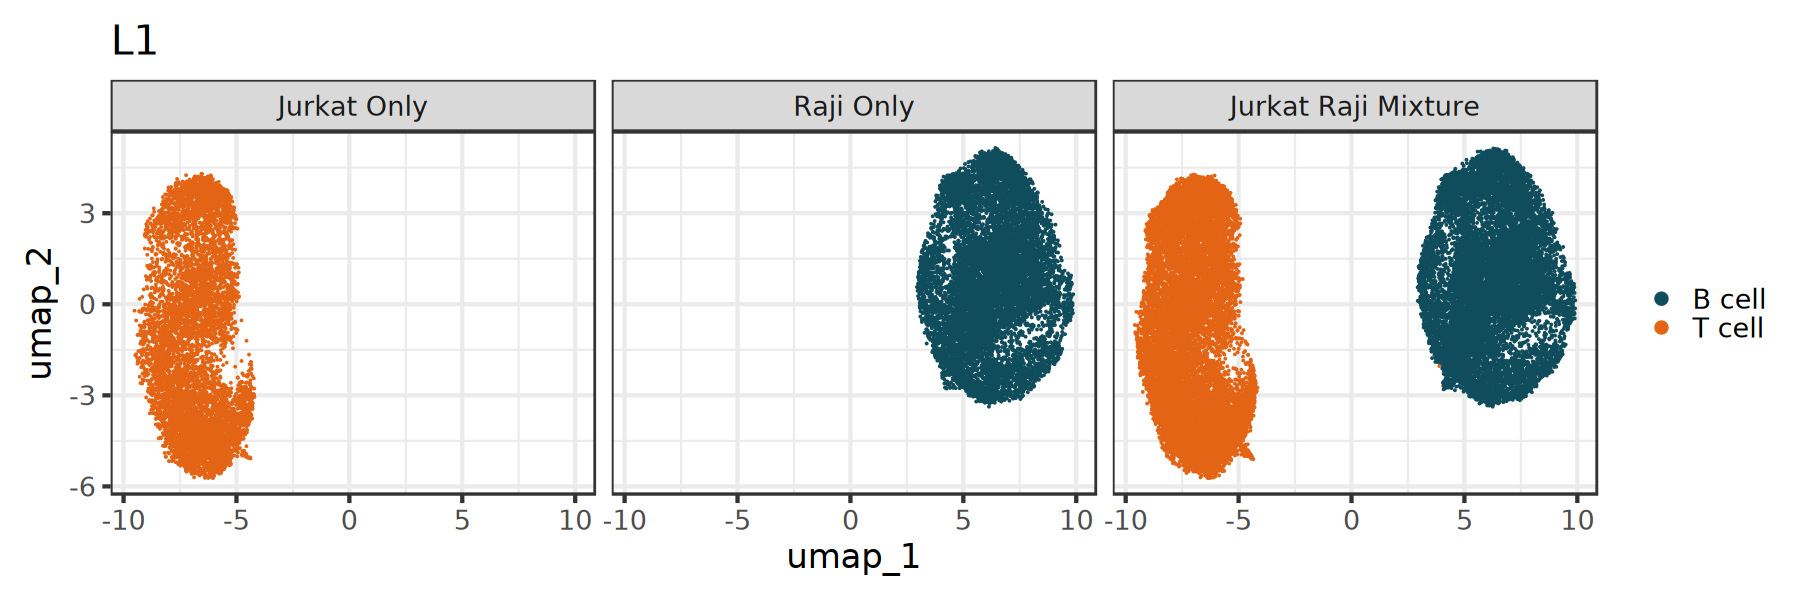

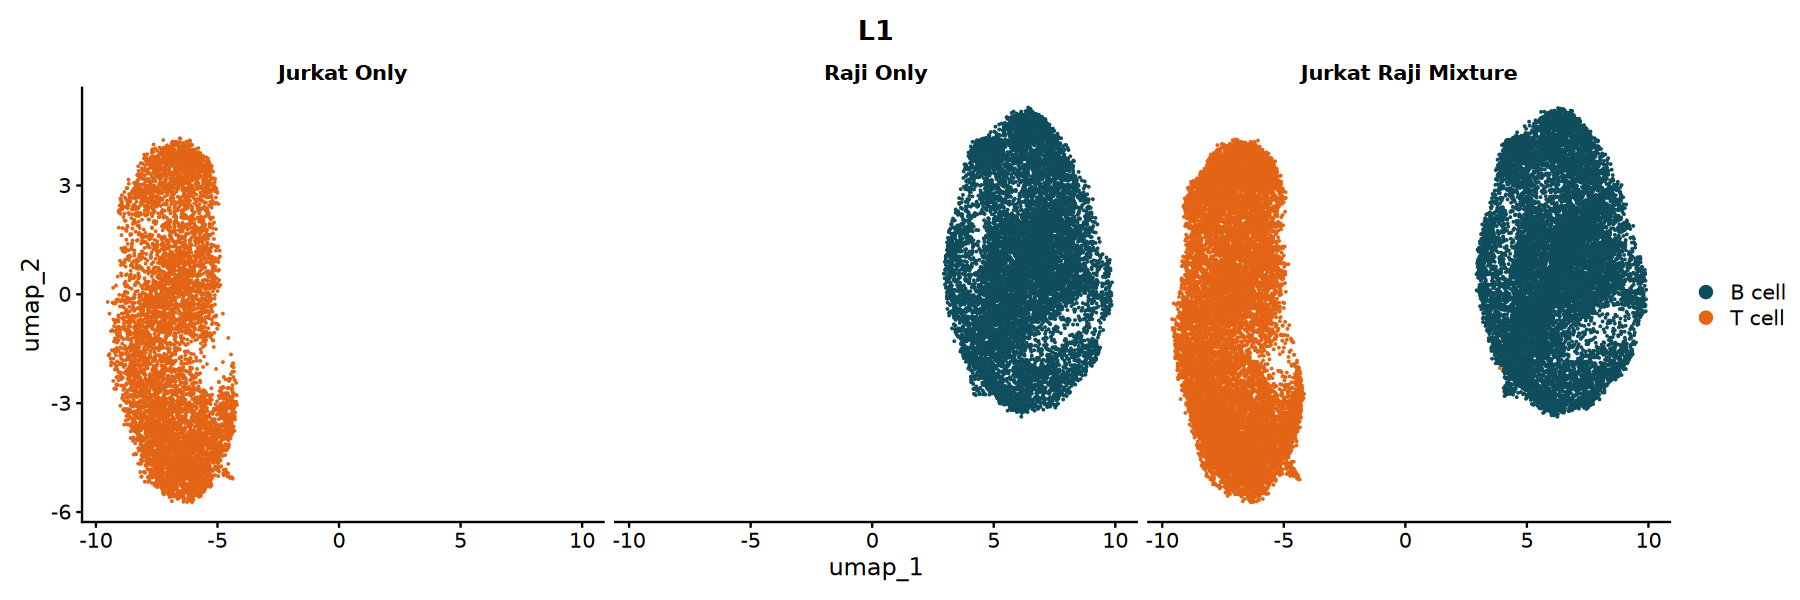

In [9]:
options(repr.plot.width = 15, repr.plot.height = 5)
so$combined_names <- factor(so$combined_names, levels = c('Jurkat Only','Raji Only','Jurkat Raji Mixture'))
DimPlot(so, group.by = 'L1', split.by = 'combined_names', ncol = 3, cols = c('#0f4c5c','#e36414')) + theme_bw(base_size = 20)
DimPlot(so, group.by = 'L1', split.by = 'combined_names', ncol = 3, cols = c('#0f4c5c','#e36414'))

In [10]:
pdf("plots/Fig1b_UMAP_Standard.pdf", width = 15, height = 5)

DimPlot(so, group.by = 'L1', split.by = 'combined_names', ncol = 3, cols = c('#0f4c5c','#e36414'))

dev.off()

pdf 
  2

In [11]:
pdf("plots/Fig1b_UMAP_theme_bw.pdf", width = 15, height = 5)

DimPlot(so, group.by = 'L1', split.by = 'combined_names', ncol = 3, cols = c('#0f4c5c','#e36414')) + theme_bw(base_size = 20)

dev.off()

pdf 
  2

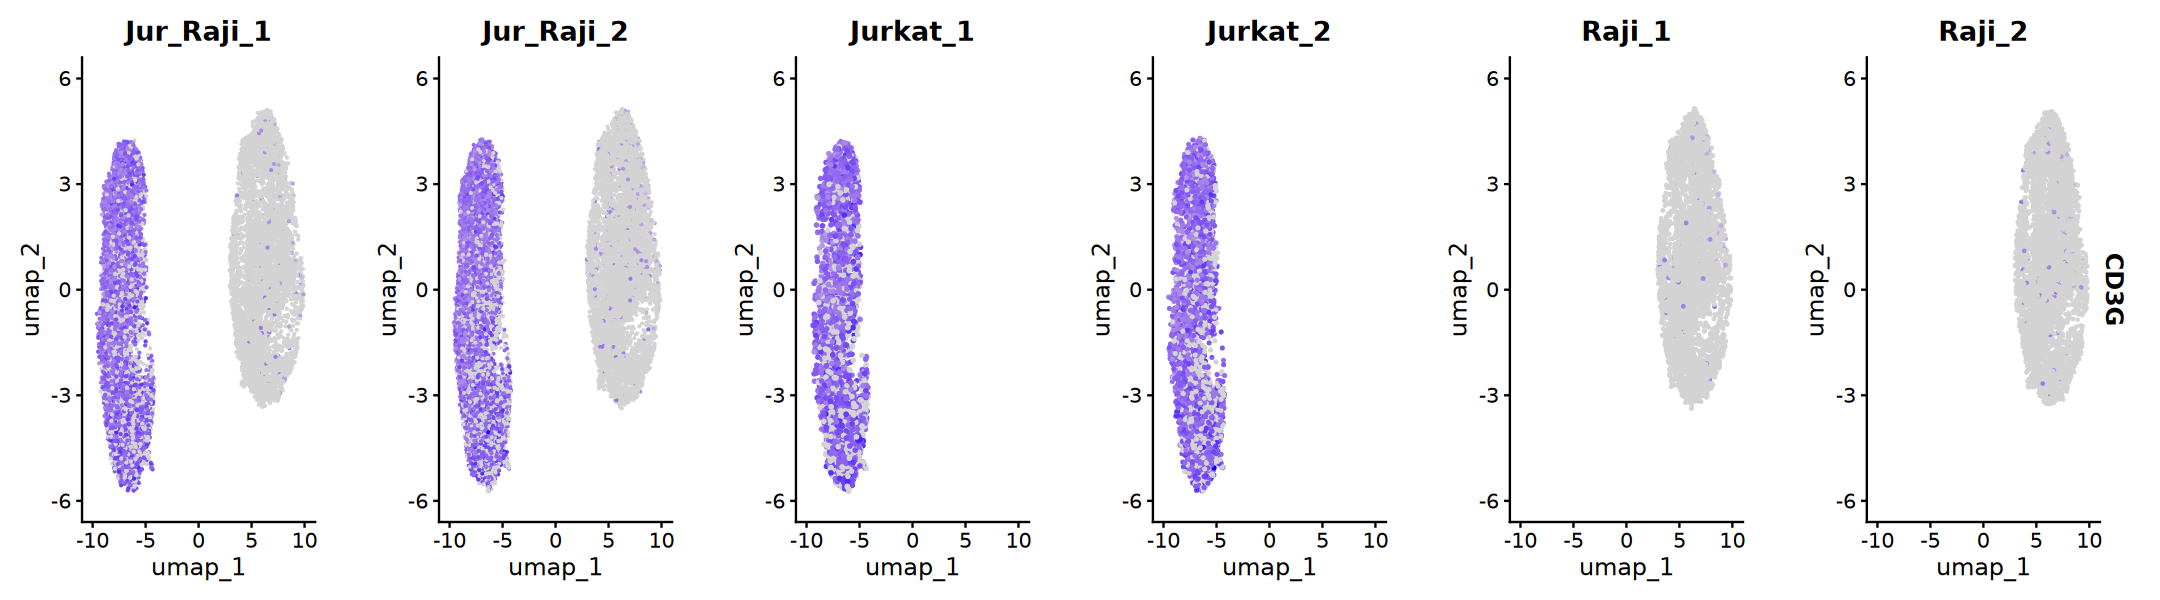

In [12]:
options(repr.plot.width = 18, repr.plot.height = 5)
FeaturePlot(so, features = 'CD3G', split.by = 'orig.ident', ncol = 6)

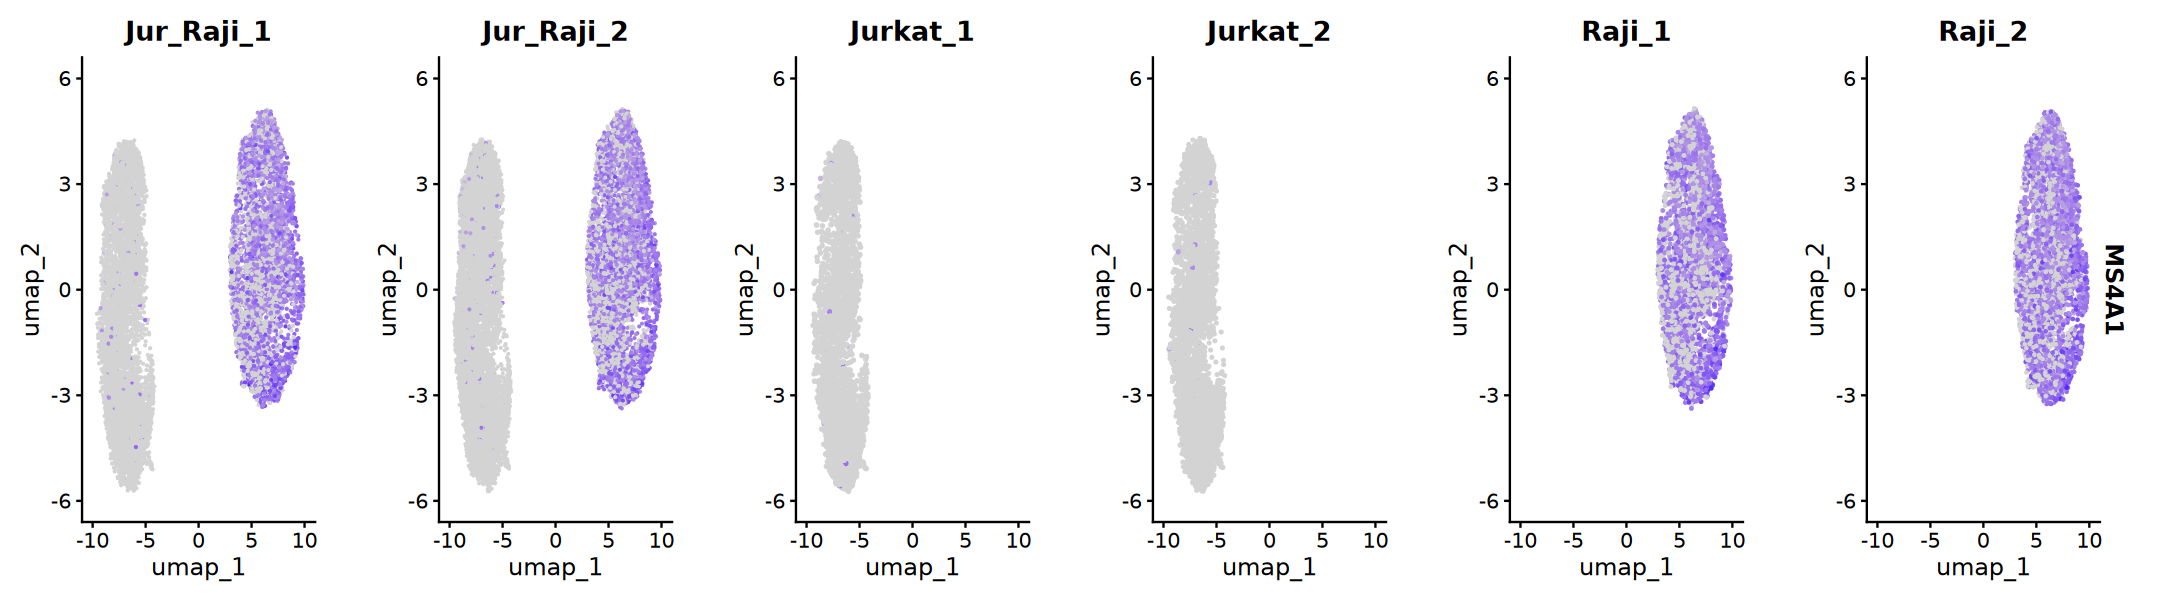

In [13]:
options(repr.plot.width = 18, repr.plot.height = 5)
FeaturePlot(so, features = 'MS4A1', split.by = 'orig.ident', ncol = 6)

# TCR Capture

In [13]:
library(stringr)

Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [14]:
so$CTgene_archive <- so$CTgene

In [15]:
so@meta.data <- so@meta.data %>%
  mutate(
    CTgene = str_remove_all(CTgene_archive, "\\*[A-Za-z0-9]+\\([0-9.]+\\)")
  )

In [16]:
so@meta.data <- so@meta.data %>%
  mutate(clone_type = case_when(
    # Case 1: Total NA (either the logical NA or the literal "NA" string)
    is.na(CTgene) | CTgene == "NA" ~ "No clone",
    
    # Case 2: Starts with NA_ (meaning Alpha is missing)
    str_detect(CTgene, "^NA_")     ~ "TRB",
    
    # Case 3: Ends with _NA (meaning Beta is missing)
    str_detect(CTgene, "_NA$")     ~ "TRA",
    
    # Case 4: Everything else (both parts have characters)
    TRUE                           ~ "TRA;TRB"
  ))

In [17]:
so@meta.data <- so@meta.data %>%
  mutate(
    # 1. Extract everything before the LAST underscore
    CDR3a = str_replace(CTaa, "_[^_]+$", ""),
    
    # 2. Extract everything after the LAST underscore
    CDR3b = str_extract(CTaa, "[^_]+$")
  ) %>%
  mutate(
    # 3. Clean up the literal "NA" strings to be actual R NAs
    CDR3a = ifelse(CDR3a == "NA", NA_character_, CDR3a),
    CDR3b = ifelse(CDR3b == "NA", NA_character_, CDR3b)
  )

In [18]:
clone_type_df <- so@meta.data %>%
                    subset(L1 != 'Progenitor cell') %>%
                    group_by(combined_names,clone_type,L1) %>%
                    dplyr::summarise(count=n()) %>%
                    dplyr::group_by(combined_names,L1) %>%
                    dplyr::mutate(percentage = (count / sum(count)) * 100)
head(clone_type_df)

combined_names,clone_type,L1,count,percentage
<fct>,<chr>,<chr>,<int>,<dbl>
Jurkat Only,No clone,T cell,1537,22.2721345
Jurkat Only,TRA,T cell,505,7.3177800
Jurkat Only,TRA;TRB,T cell,2543,36.8497319
Jurkat Only,TRB,T cell,2316,33.5603536
Raji Only,No clone,B cell,10388,97.9353257
Raji Only,TRA,B cell,21,0.1979825


In [19]:
so <- JoinLayers(so)

In [20]:
gex_df <- data.frame(CD3G = GetAssayData(so, layer="counts")['CD3G',],
                     combined_names = so$combined_names,
                     L1 = so$L1)
head(gex_df)

,CD3G,combined_names,L1
,<dbl>,<fct>,<chr>
AAACCAATCACGGACAACAGACCT-1,1,Jurkat Only,T cell
AAACCAATCCGCACCAACAGACCT-1,3,Jurkat Only,T cell
AAACCAATCCTCACGGACAGACCT-1,1,Jurkat Only,T cell
AAACCAATCTAATCGTACAGACCT-1,2,Jurkat Only,T cell
AAACCAGGTCCTGAGCACAGACCT-1,0,Jurkat Only,T cell
AAACCAGGTGGAAGCTACAGACCT-1,3,Jurkat Only,T cell


In [21]:
gex_df$clone_type <- 'CD3G Negative'
gex_df$clone_type[gex_df$CD3G >= 1] <- 'CD3G Positive'
table(gex_df$clone_type)


CD3G Negative CD3G Positive 
        28358         15671 

In [22]:
gex_df$L1 <- paste0(gex_df$L1,'_gex')

In [23]:
gex_df_summary <- gex_df %>%
                    subset(L1 != 'Progenitor cell') %>%
                    group_by(combined_names,clone_type,L1) %>%
                    dplyr::summarise(count=n()) %>%
                    dplyr::group_by(combined_names,L1) %>%
                    dplyr::mutate(percentage = (count / sum(count)) * 100)
head(gex_df_summary)

combined_names,clone_type,L1,count,percentage
<fct>,<chr>,<chr>,<int>,<dbl>
Jurkat Only,CD3G Negative,T cell_gex,1885,27.314882
Jurkat Only,CD3G Positive,T cell_gex,5016,72.685118
Raji Only,CD3G Negative,B cell_gex,10390,97.954181
Raji Only,CD3G Positive,B cell_gex,217,2.045819
Jurkat Raji Mixture,CD3G Negative,B cell_gex,12169,96.266118
Jurkat Raji Mixture,CD3G Negative,T cell_gex,3914,28.198847


In [24]:
df_combined <- rbind(clone_type_df, gex_df_summary)

In [26]:
unique(df_combined$clone_type)

[1] "No clone"      "TRA"           "TRA;TRB"       "TRB"          
[5] "CD3G Negative" "CD3G Positive"

## Plot (Fig1b)

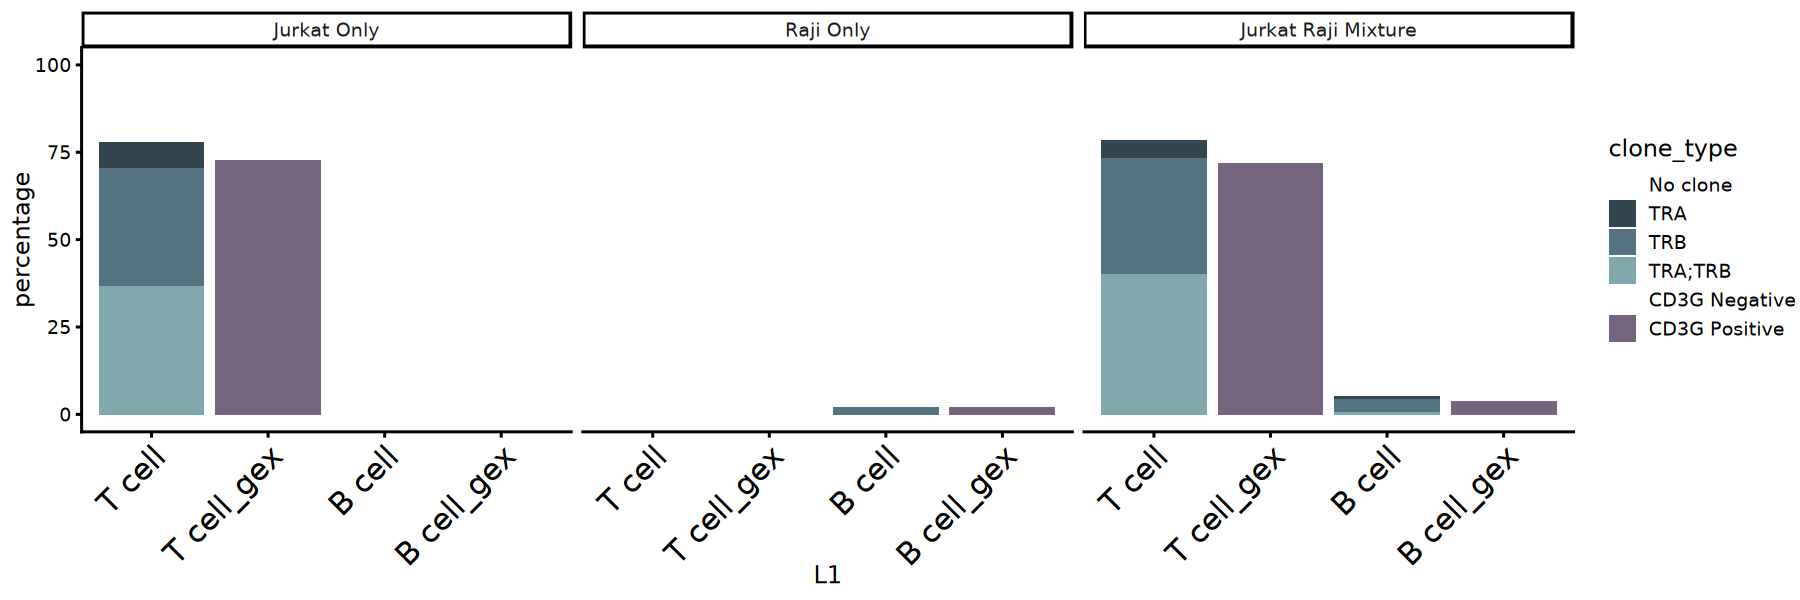

In [30]:
options(repr.plot.width = 15, repr.plot.height = 5)
df_combined %>%
    mutate(clone_type = factor(clone_type, levels = c('No clone','TRA','TRB','TRA;TRB','CD3G Negative','CD3G Positive'))) %>%
    mutate(L1 = factor(L1, levels = c('T cell','T cell_gex','B cell','B cell_gex'))) %>%
    ggplot(aes(x = L1, y = percentage, fill = clone_type)) + 
      geom_bar(stat = 'identity', position = 'stack') + 
      # geom_text(aes(label = round(proportion, 2)), 
      #           position = position_stack(vjust = 0.5), 
      #           size = 4, color = "black") +
      facet_wrap(facets = vars(combined_names), ncol = 6) +
      theme_classic(base_size = 14) + 
      scale_fill_manual(values = c('transparent','#33454e','#537380','#81a9ad','transparent','#74647e')) +
      theme(legend.position = 'right', axis.text.x = element_text(size=18, angle = 45, hjust=1,vjust=1))

In [31]:
pdf("plots/Fig1b_tcr_clone_type_barplot.pdf", width = 15, height = 5)

df_combined %>%
    mutate(clone_type = factor(clone_type, levels = c('No clone','TRA','TRB','TRA;TRB','CD3G Negative','CD3G Positive'))) %>%
    mutate(L1 = factor(L1, levels = c('T cell','T cell_gex','B cell','B cell_gex'))) %>%
    ggplot(aes(x = L1, y = percentage, fill = clone_type)) + 
      geom_bar(stat = 'identity', position = 'stack') + 
      # geom_text(aes(label = round(proportion, 2)), 
      #           position = position_stack(vjust = 0.5), 
      #           size = 4, color = "black") +
      facet_wrap(facets = vars(combined_names), ncol = 6) +
      theme_classic(base_size = 14) + 
      scale_fill_manual(values = c('transparent','#33454e','#537380','#81a9ad','transparent','#74647e')) +
      theme(legend.position = 'right', axis.text.x = element_text(size=18, angle = 45, hjust=1,vjust=1))

dev.off()

pdf 
  2

# TCR VJ Usage

## TRA

In [46]:
tra <- subset(so, clone_type %in% c('TRA','TRA;TRB') & L1 == 'T cell')

In [57]:
tra$correct_tra <- 'Other'
tra$correct_tra[grep(x = tra$CTgene, pattern = 'TRAV8-4')] <- 'TRAV8-4'

In [58]:
tra_vj_usage <- tra@meta.data %>%
    group_by(correct_tra) %>%
    summarise(count = n()) %>%
    mutate(percentage = count / sum(count)*100)
tra_vj_usage

correct_tra,count,percentage
<chr>,<int>,<dbl>
Other,5,0.05352746
TRAV8-4,9336,99.94647254


## TRB

In [50]:
trb <- subset(so, clone_type %in% c('TRB','TRA;TRB') & L1 == 'T cell')

In [59]:
trb$correct_trb <- 'Other'
trb$correct_trb[grep(x = trb$CTgene, pattern = 'TRBV12-4')] <- 'TRBV12-4'

In [60]:
trb_vj_usage <- trb@meta.data %>%
    group_by(correct_trb) %>%
    summarise(count = n()) %>%
    mutate(percentage = count / sum(count)*100)
trb_vj_usage

correct_trb,count,percentage
<chr>,<int>,<dbl>
Other,5,0.03329116
TRBV12-4,15014,99.96670884


In [56]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] stringr_1.6.0      future_1.58.0      scRepertoire_2.5.3 ggplot2_4.0.3     
[5] dplyr_1.2.1        Seurat_5.3.0       SeuratObject_5.0.2 sp_2.2-0          

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22            splines_4.4.1              
  [3] later_1.4.2                 pbdZMQ_0.3-14        